# StockSight - 04 · Evaluation: Metrics, Benchmarks & Backtest

Brings the models together: predictive **metrics**, a **per-horizon** comparison, and the
**Top-K daily-rebalance backtest** against SPY / equal-weight buy-and-hold / cash. Everything is
**loaded from precomputed results** (`results/*.csv`, `results/backtest_equity.parquet`).

In [1]:
# === Setup (shared across the StockSight notebook suite) ===
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Locate the project root (the folder that holds config.yaml) and put it on sys.path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({"figure.figsize": (11, 4), "figure.dpi": 110})
sns.set_style("whitegrid")
sns.set_palette("deep")
HEATMAP_CMAP = "RdBu_r"
SEED = 42

from src.config import RESULTS_DIR, MODELS_DIR, CFG

print("Project root :", ROOT)
print("Universe     :", len(CFG["tickers"]), "tickers ->", ", ".join(CFG["tickers"]))

Project root : F:\AIProjects\stocksight
Universe     : 21 tickers -> NDSN, HON, BKR, APA, CSX, JBHT, FAST, FELE, GT, FITB, NTRS, EA, AEP, AMGN, COST, ROST, PEP, KMB, MAT, HAS, NWL


## Methodology - three lenses

1. **Predictive metrics** - error (MAE/RMSE/MAPE) and **directional accuracy** (the comparable axis: ML predicts the 1-day sign, DL the 14-day sign).
2. **Per-horizon** - how error grows when ML forecasts multi-step *recursively* vs DL emitting all 14 days *at once*.
3. **Backtest** - a realistic trading sim: long-only, equal-weight the **top-5** tickers whose signal clears a **0.5%** threshold; the position on day *t* is set by the signal from day *t-1* (**no look-ahead**); **10 bps** cost per trade. Strategies and benchmarks (SPY, equal-weight buy-&-hold, cash) are trimmed to a **common date window** for a fair comparison.

Metrics tell us if the model is right; the backtest tells us if being right *makes money* after costs. The no-look-ahead rule and common window are what make this trustworthy rather than a backtest fantasy.

## 1 · Predictive metrics - ML vs DL

Directional accuracy is the shared yardstick (ML = 1-day sign; DL = per-day and 14-day sign).

ML models cluster at **~0.49-0.50** (coin flip); DL reaches **~0.55 per-day** and **~0.54 at t+14**. The red line is the 0.50 break-even - only the DL bars clear it.

,directional_accuracy
ML ridge,0.488
ML rf_reg,0.504
ML xgb_reg,0.492
DL per-day,0.546
DL t+14,0.536


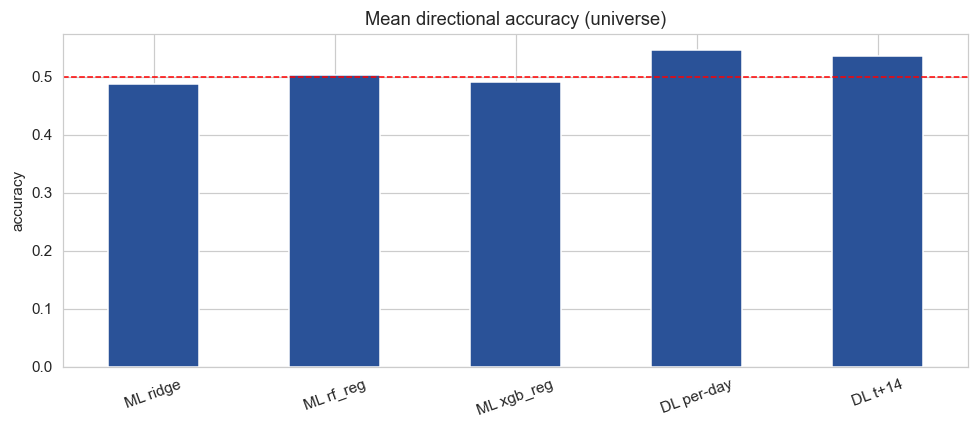

In [2]:
ml = pd.read_csv(RESULTS_DIR / "ml_summary.csv")
dl = pd.read_csv(RESULTS_DIR / "dl_summary.csv")

ml_dir = (ml[ml["model"].isin(["ridge", "rf_reg", "xgb_reg"])]
          .groupby("model")["directional_accuracy"].mean())
summary = pd.DataFrame({
    "directional_accuracy": {
        "ML ridge":  ml_dir.get("ridge"),
        "ML rf_reg": ml_dir.get("rf_reg"),
        "ML xgb_reg": ml_dir.get("xgb_reg"),
        "DL per-day": dl["test_dir_accuracy_perday"].mean(),
        "DL t+14":   dl["test_dir_accuracy_t14"].mean(),
    }
})
display(summary.round(3))

ax = summary["directional_accuracy"].plot(kind="bar", figsize=(9, 4),
                                          color="#2a5298")
ax.axhline(0.5, color="red", ls="--", lw=1)
ax.set_title("Mean directional accuracy (universe)"); ax.set_ylabel("accuracy")
ax.tick_params(axis="x", rotation=20); plt.tight_layout(); plt.show()

## 2 · Per-horizon error - ML recursive vs DL seq2seq

ML has no native multi-step output, so it forecasts day-by-day by **feeding its own predictions back in** (errors accumulate). DL emits all 14 days in **one shot**.

The ML curve rises faster with horizon - recursive error build-up - while the purpose-built DL sequence model degrades more gracefully. The right tool for a multi-day forecast.

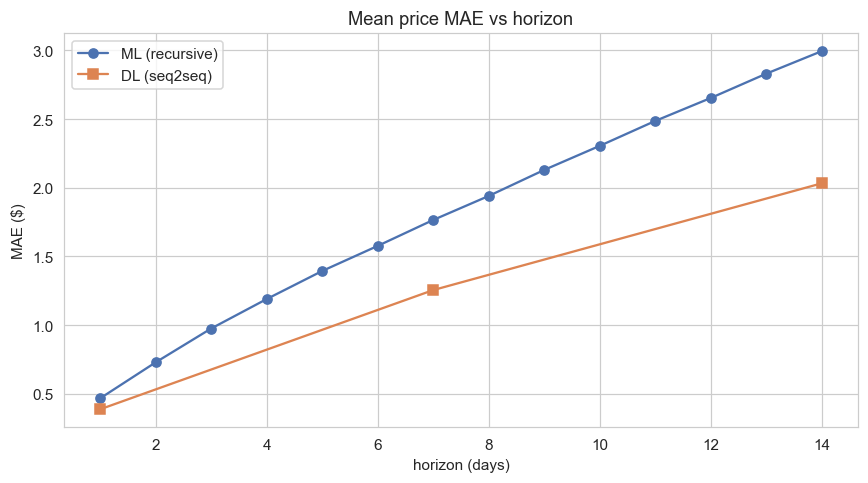

In [3]:
ph = pd.read_csv(RESULTS_DIR / "per_horizon_ml.csv")
ml_ph = ph.groupby("horizon")["mae_price"].mean()

days = [1, 7, 14]
dl_ph = dl[[f"test_mae_price_d{d}" for d in days]].mean()
dl_ph.index = days

plt.figure(figsize=(8, 4.5))
plt.plot(ml_ph.index, ml_ph.values, marker="o", label="ML (recursive)")
plt.plot(dl_ph.index, dl_ph.values, marker="s", label="DL (seq2seq)")
plt.title("Mean price MAE vs horizon"); plt.xlabel("horizon (days)")
plt.ylabel("MAE ($)"); plt.legend(); plt.tight_layout(); plt.show()

## 3 · Backtest summary - the bottom line

Nine strategies on the common window. **This is the decisive table.**

| Strategy | Sharpe | Total return | Max drawdown |
|---|---|---|---|
| **DL_seq2seq** | **~1.18** | **+71%** | -13% |
| ML ridge / rf / xgb | -0.26 / 0.30 / -0.52 | ≤ +3% | up to -20% |
| SPY (benchmark) | ~1.25 | +83% | -10% |
| Equal-weight B&H | ~1.30 | +98% | -9% |

- **DL is the only model strategy that makes real money** (Sharpe ~1.18) - close to, but still below, the market benchmarks.
- **ML signals are flat-to-negative** - consistent with their coin-flip accuracy.

The deep-learning signal turns its directional edge into a genuinely investable equity curve, landing just shy of buy-and-hold; the classical models don't clear the cost hurdle. The table also reports hit-rate, turnover, and alpha vs SPY with its t-stat.

In [4]:
bt = pd.read_csv(RESULTS_DIR / "backtest_summary.csv").set_index("strategy")
show = ["total_return", "ann_return", "ann_vol", "sharpe", "max_dd",
        "hit_rate", "avg_turnover", "alpha_vs_bench", "tstat_alpha"]
display(bt[show].round(3))

,total_return,ann_return,ann_vol,sharpe,max_dd,hit_rate,avg_turnover,alpha_vs_bench,tstat_alpha
strategy,,,,,,,,,
DL_seq2seq,0.713,0.150,0.127,1.185,-0.126,0.549,0.150,0.028,0.629
ML_ridge,-0.029,-0.007,0.029,-0.257,-0.091,0.050,0.019,-0.014,-0.973
ML_rf_reg,0.026,0.007,0.024,0.301,-0.038,0.052,0.014,0.000,0.012
ML_xgb_reg,-0.188,-0.050,0.097,-0.517,-0.201,0.379,0.211,-0.122,-2.982
ML_naive_zero,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN
ML_naive_persistence,-0.624,-0.248,0.143,-1.734,-0.643,0.408,0.606,-0.386,-7.603
SPY,0.830,0.158,0.126,1.253,-0.097,0.556,0.000,-0.000,-90.318
EW_BuyHold,0.978,0.179,0.138,1.297,-0.094,0.559,0.000,0.016,0.667
Cash,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN


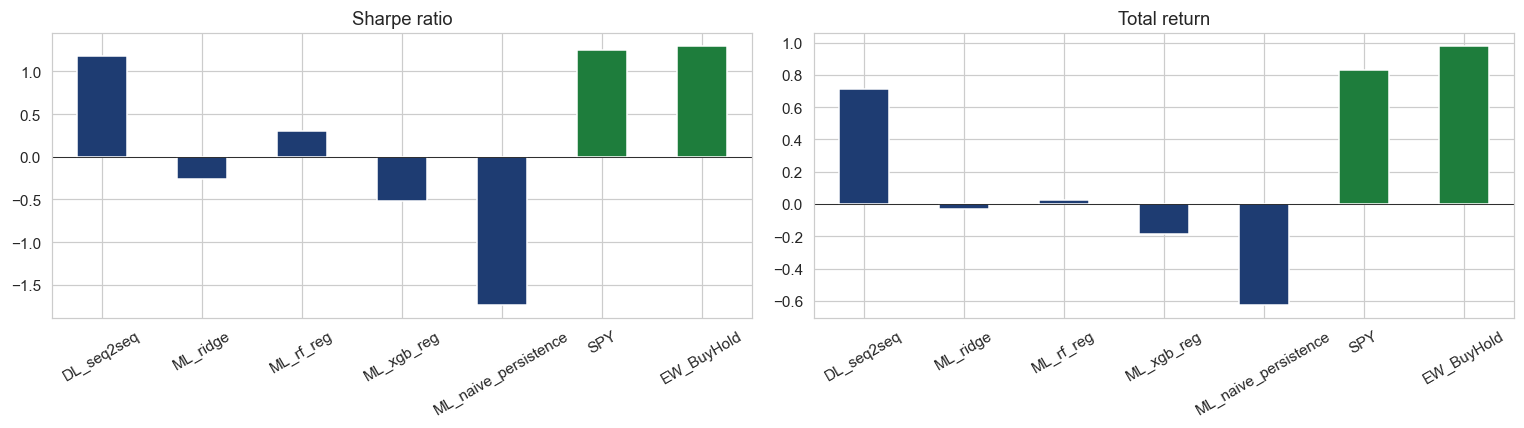

In [5]:
order = ["DL_seq2seq", "ML_ridge", "ML_rf_reg", "ML_xgb_reg",
         "ML_naive_persistence", "SPY", "EW_BuyHold"]
order = [s for s in order if s in bt.index]
colors = ["#1e3c72" if s.startswith(("DL", "ML")) else "#1e7d3c" for s in order]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
bt.loc[order, "sharpe"].plot(kind="bar", ax=ax[0], color=colors)
ax[0].axhline(0, color="black", lw=0.5); ax[0].set_title("Sharpe ratio")
bt.loc[order, "total_return"].plot(kind="bar", ax=ax[1], color=colors)
ax[1].axhline(0, color="black", lw=0.5); ax[1].set_title("Total return")
for a in ax:
    a.set_xlabel(""); a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## 4 · Equity curves & drawdown

Re-rendered from the saved equity panel. **Top** - cumulative equity (log scale, all starting at 1.0); **bottom** - drawdown (depth/duration of losses). Solid = strategies, dashed = benchmarks.

DL_seq2seq (blue) compounds alongside SPY / equal-weight with a comparable drawdown profile, while the ML lines stay flat near 1.0. The log scale makes the compounding gap easy to read.

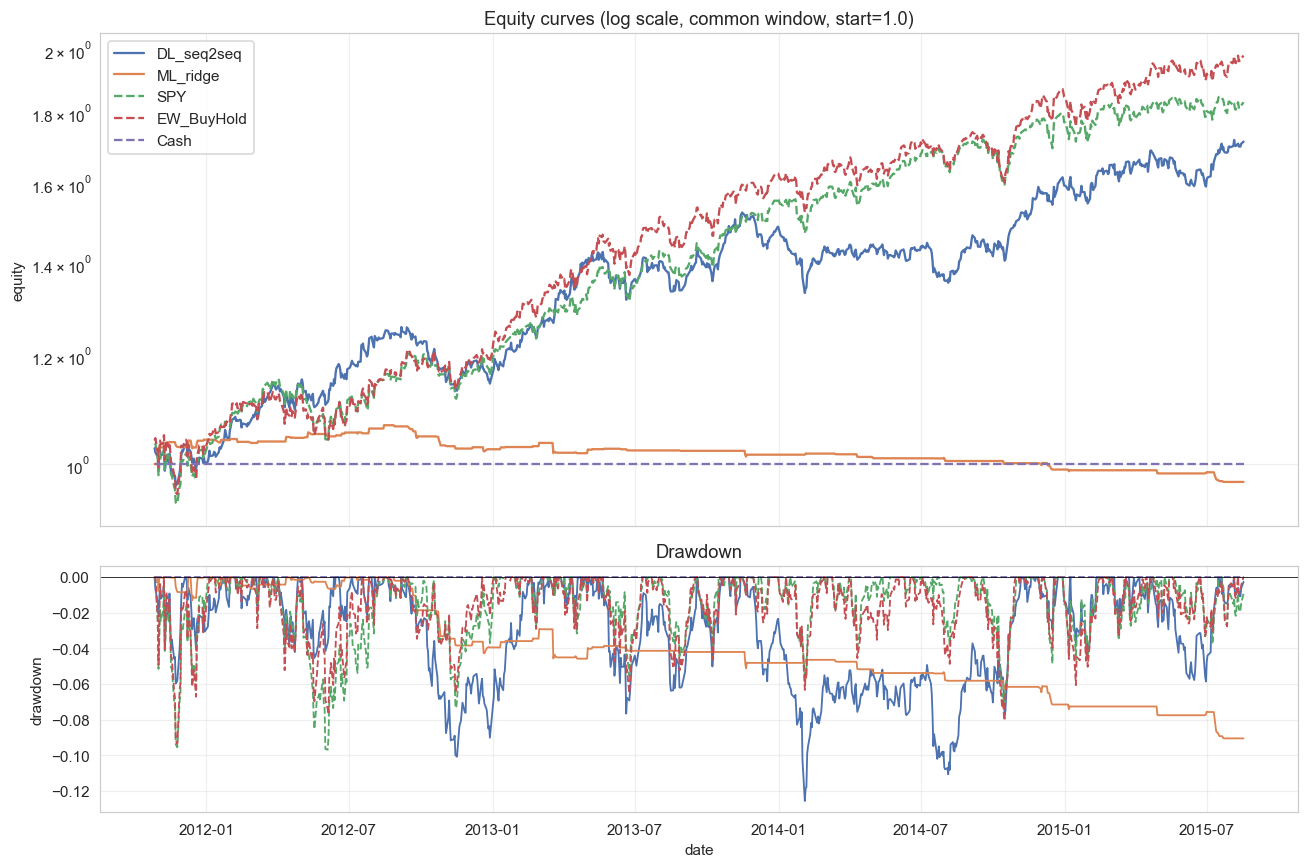

In [6]:
eq = pd.read_parquet(RESULTS_DIR / "backtest_equity.parquet")
eq["date"] = pd.to_datetime(eq["date"])
wide = eq.pivot(index="date", columns="strategy", values="equity").sort_index()

main = [s for s in ["DL_seq2seq", "ML_ridge", "SPY", "EW_BuyHold", "Cash"] if s in wide.columns]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
for s in main:
    ls = "--" if s in ("SPY", "EW_BuyHold", "Cash") else "-"
    ax1.plot(wide.index, wide[s], label=s, lw=1.5, ls=ls)
ax1.set_yscale("log"); ax1.set_title("Equity curves (log scale, common window, start=1.0)")
ax1.set_ylabel("equity"); ax1.legend(loc="upper left"); ax1.grid(True, alpha=0.3)

for s in main:
    dd = wide[s] / wide[s].cummax() - 1.0
    ls = "--" if s in ("SPY", "EW_BuyHold", "Cash") else "-"
    ax2.plot(wide.index, dd, label=s, lw=1.2, ls=ls)
ax2.axhline(0, color="black", lw=0.5); ax2.set_title("Drawdown")
ax2.set_ylabel("drawdown"); ax2.set_xlabel("date"); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 5 · Cost sensitivity

Sharpe re-computed at **0, 5, 10, 20 bps** per trade. High-turnover signals decay fastest as costs rise.

We stress-test the cost assumption. The DL strategy keeps a positive Sharpe across realistic cost levels, whereas the high-turnover ML signals erode quickly - so the DL result isn't an artifact of an optimistic cost number.

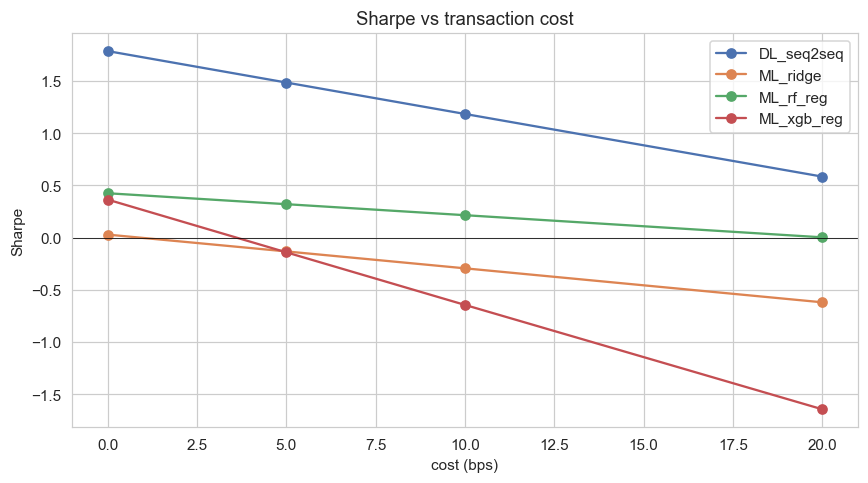

strategy,DL_seq2seq,ML_ridge,ML_rf_reg,ML_xgb_reg
cost_bp,,,,
0,1.787,0.028,0.424,0.364
5,1.485,-0.133,0.320,-0.142
10,1.184,-0.295,0.214,-0.646
20,0.584,-0.621,0.002,-1.646


In [7]:
cs = pd.read_csv(RESULTS_DIR / "backtest_cost_sensitivity.csv")
pivot = cs.pivot(index="cost_bp", columns="strategy", values="sharpe")
keep = [c for c in ["DL_seq2seq", "ML_ridge", "ML_rf_reg", "ML_xgb_reg"] if c in pivot.columns]

plt.figure(figsize=(8, 4.5))
for c in keep:
    plt.plot(pivot.index, pivot[c], marker="o", label=c)
plt.axhline(0, color="black", lw=0.5)
plt.title("Sharpe vs transaction cost"); plt.xlabel("cost (bps)"); plt.ylabel("Sharpe")
plt.legend(); plt.tight_layout(); plt.show()
display(pivot[keep].round(3))

## 6 · Risk-return profile

Each strategy as a dot: **x = annualised volatility, y = annualised return.** Dashed grey lines are iso-Sharpe (0.5 / 1.0 / 1.5) - further up-and-left is better.

DL_seq2seq sits on roughly the same Sharpe ≈ 1.2 ray as SPY and equal-weight buy-&-hold (green), well above the ML dots clustered near zero/negative return.

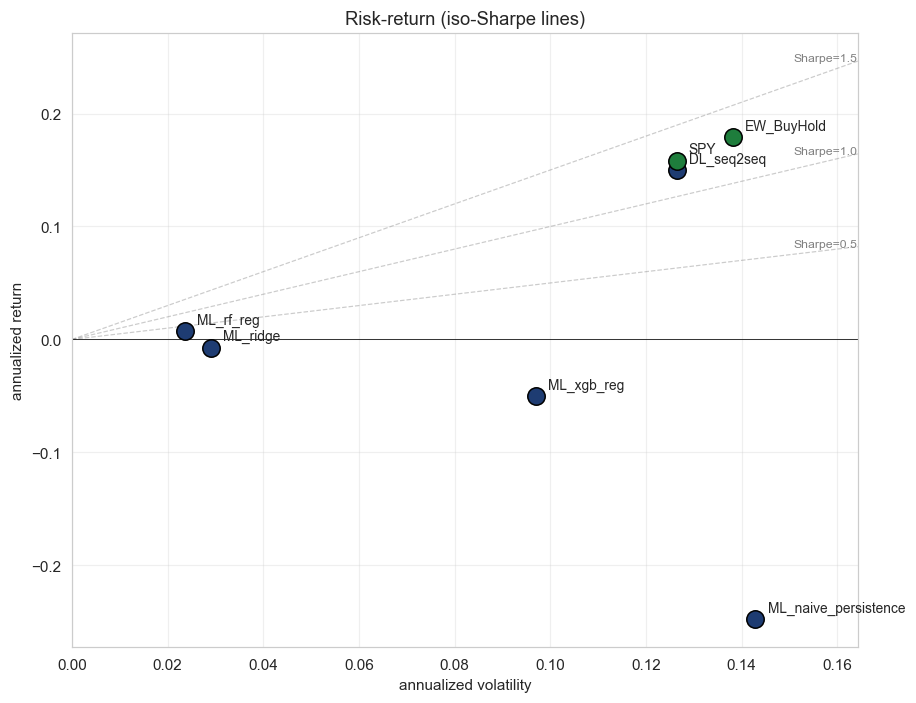

In [8]:
df = bt[bt["ann_vol"] > 1e-6].reset_index()
x_max = float(df["ann_vol"].max()) * 1.15

plt.figure(figsize=(8.5, 6.5))
for s_iso in [0.5, 1.0, 1.5]:
    plt.plot([0, x_max], [0, s_iso * x_max], "--", color="gray", alpha=0.4, lw=0.8)
    plt.annotate(f"Sharpe={s_iso}", xy=(x_max, s_iso * x_max), fontsize=8,
                 color="gray", ha="right")
for _, r in df.iterrows():
    is_bench = r["strategy"] in ("SPY", "EW_BuyHold", "Cash")
    plt.scatter(r["ann_vol"], r["ann_return"], s=130,
                color="#1e7d3c" if is_bench else "#1e3c72", edgecolor="black", zorder=5)
    plt.annotate(r["strategy"], (r["ann_vol"], r["ann_return"]),
                 xytext=(8, 5), textcoords="offset points", fontsize=9)
plt.axhline(0, color="black", lw=0.5)
plt.xlabel("annualized volatility"); plt.ylabel("annualized return")
plt.title("Risk-return (iso-Sharpe lines)"); plt.xlim(0, x_max)
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 7 · Conclusion

| Dimension | Finding |
|---|---|
| **Point accuracy** | Next-day return prediction is near-noise for all ML models (MAE ≈ naive, R² < 0). |
| **Direction** | DL seq2seq clears 0.50 on the t+14 sign (~0.54); ML stays at a coin flip (~0.49-0.50). |
| **Backtest** | `DL_seq2seq` is the only model strategy with a healthy Sharpe (~1.18, +71%), landing just below SPY (~1.25) and equal-weight B&H (~1.30) on the common window. |
| **Costs** | The DL edge is the most robust to rising transaction costs; high-turnover ML signals decay quickly. |

**Bottom line:** framing the problem as a **14-day directional sequence** (DL) is far more tradeable than chasing exact next-day returns (ML) - but on this universe it still does not *beat* simply holding the market. The real deliverable is an **honest, leakage-free evaluation harness** (chronological splits, no look-ahead, cost-aware backtest) that makes that conclusion trustworthy.

Our best model earns a market-like return with a market-like risk profile and survives realistic costs - and just as important, our evaluation is rigorous enough that we trust the result instead of overselling it.